In [1]:
%load_ext autoreload
%autoreload 2

In [101]:
from data_processing import DataProcessor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import classification_report, auc
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import RandomizedSearchCV
from hyperopt import hp
from hyperopt.pyll.base import scope
from autogluon.tabular import TabularPredictor
import shap

In [4]:
# Read data from file
raw_df = pd.read_csv('bank-additional-full.csv', sep=';')
raw_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [6]:
# Check whether target values are balanced
raw_df.y.value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

# Explorartory Data Analysis

In [5]:
# Function for calculating non-outliers bounds
def get_regular_bounds(column_data: pd.Series):
    Q1 = column_data.quantile(0.25)
    Q3 = column_data.quantile(0.75)
    IQR = Q3 - Q1

    min_value = (Q1 - 1.5 * IQR)
    max_value = (Q3 + 1.5 * IQR)

    return {'min': min_value, 'max': max_value}

In [7]:
# Check basic columns info
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Observation.** We can see, that there are no missing values in this dataset.

In [8]:
# Separate input columns and from them: numeric and categorical
input_cols = raw_df.columns.drop(['y']).to_list()
numeric_cols = raw_df[input_cols].select_dtypes(include='number').columns.to_list()
categorical_cols = raw_df[input_cols].select_dtypes(include='object').columns.to_list()
len(numeric_cols), len(categorical_cols)

(10, 10)

In [9]:
# Transform target to numeric values
target_map = {'yes': 1, 'no': 0}
raw_df['y'] = raw_df['y'].map(target_map)

raw_df['y']

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 41188, dtype: int64

## Numeric columns

In [10]:
# Check number of unique values in each numeric column
raw_df[numeric_cols].nunique()

age                 78
duration          1544
campaign            42
pdays               27
previous             8
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
dtype: int64

In [11]:
# Show statistical info for each numeric column
raw_df[numeric_cols].describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


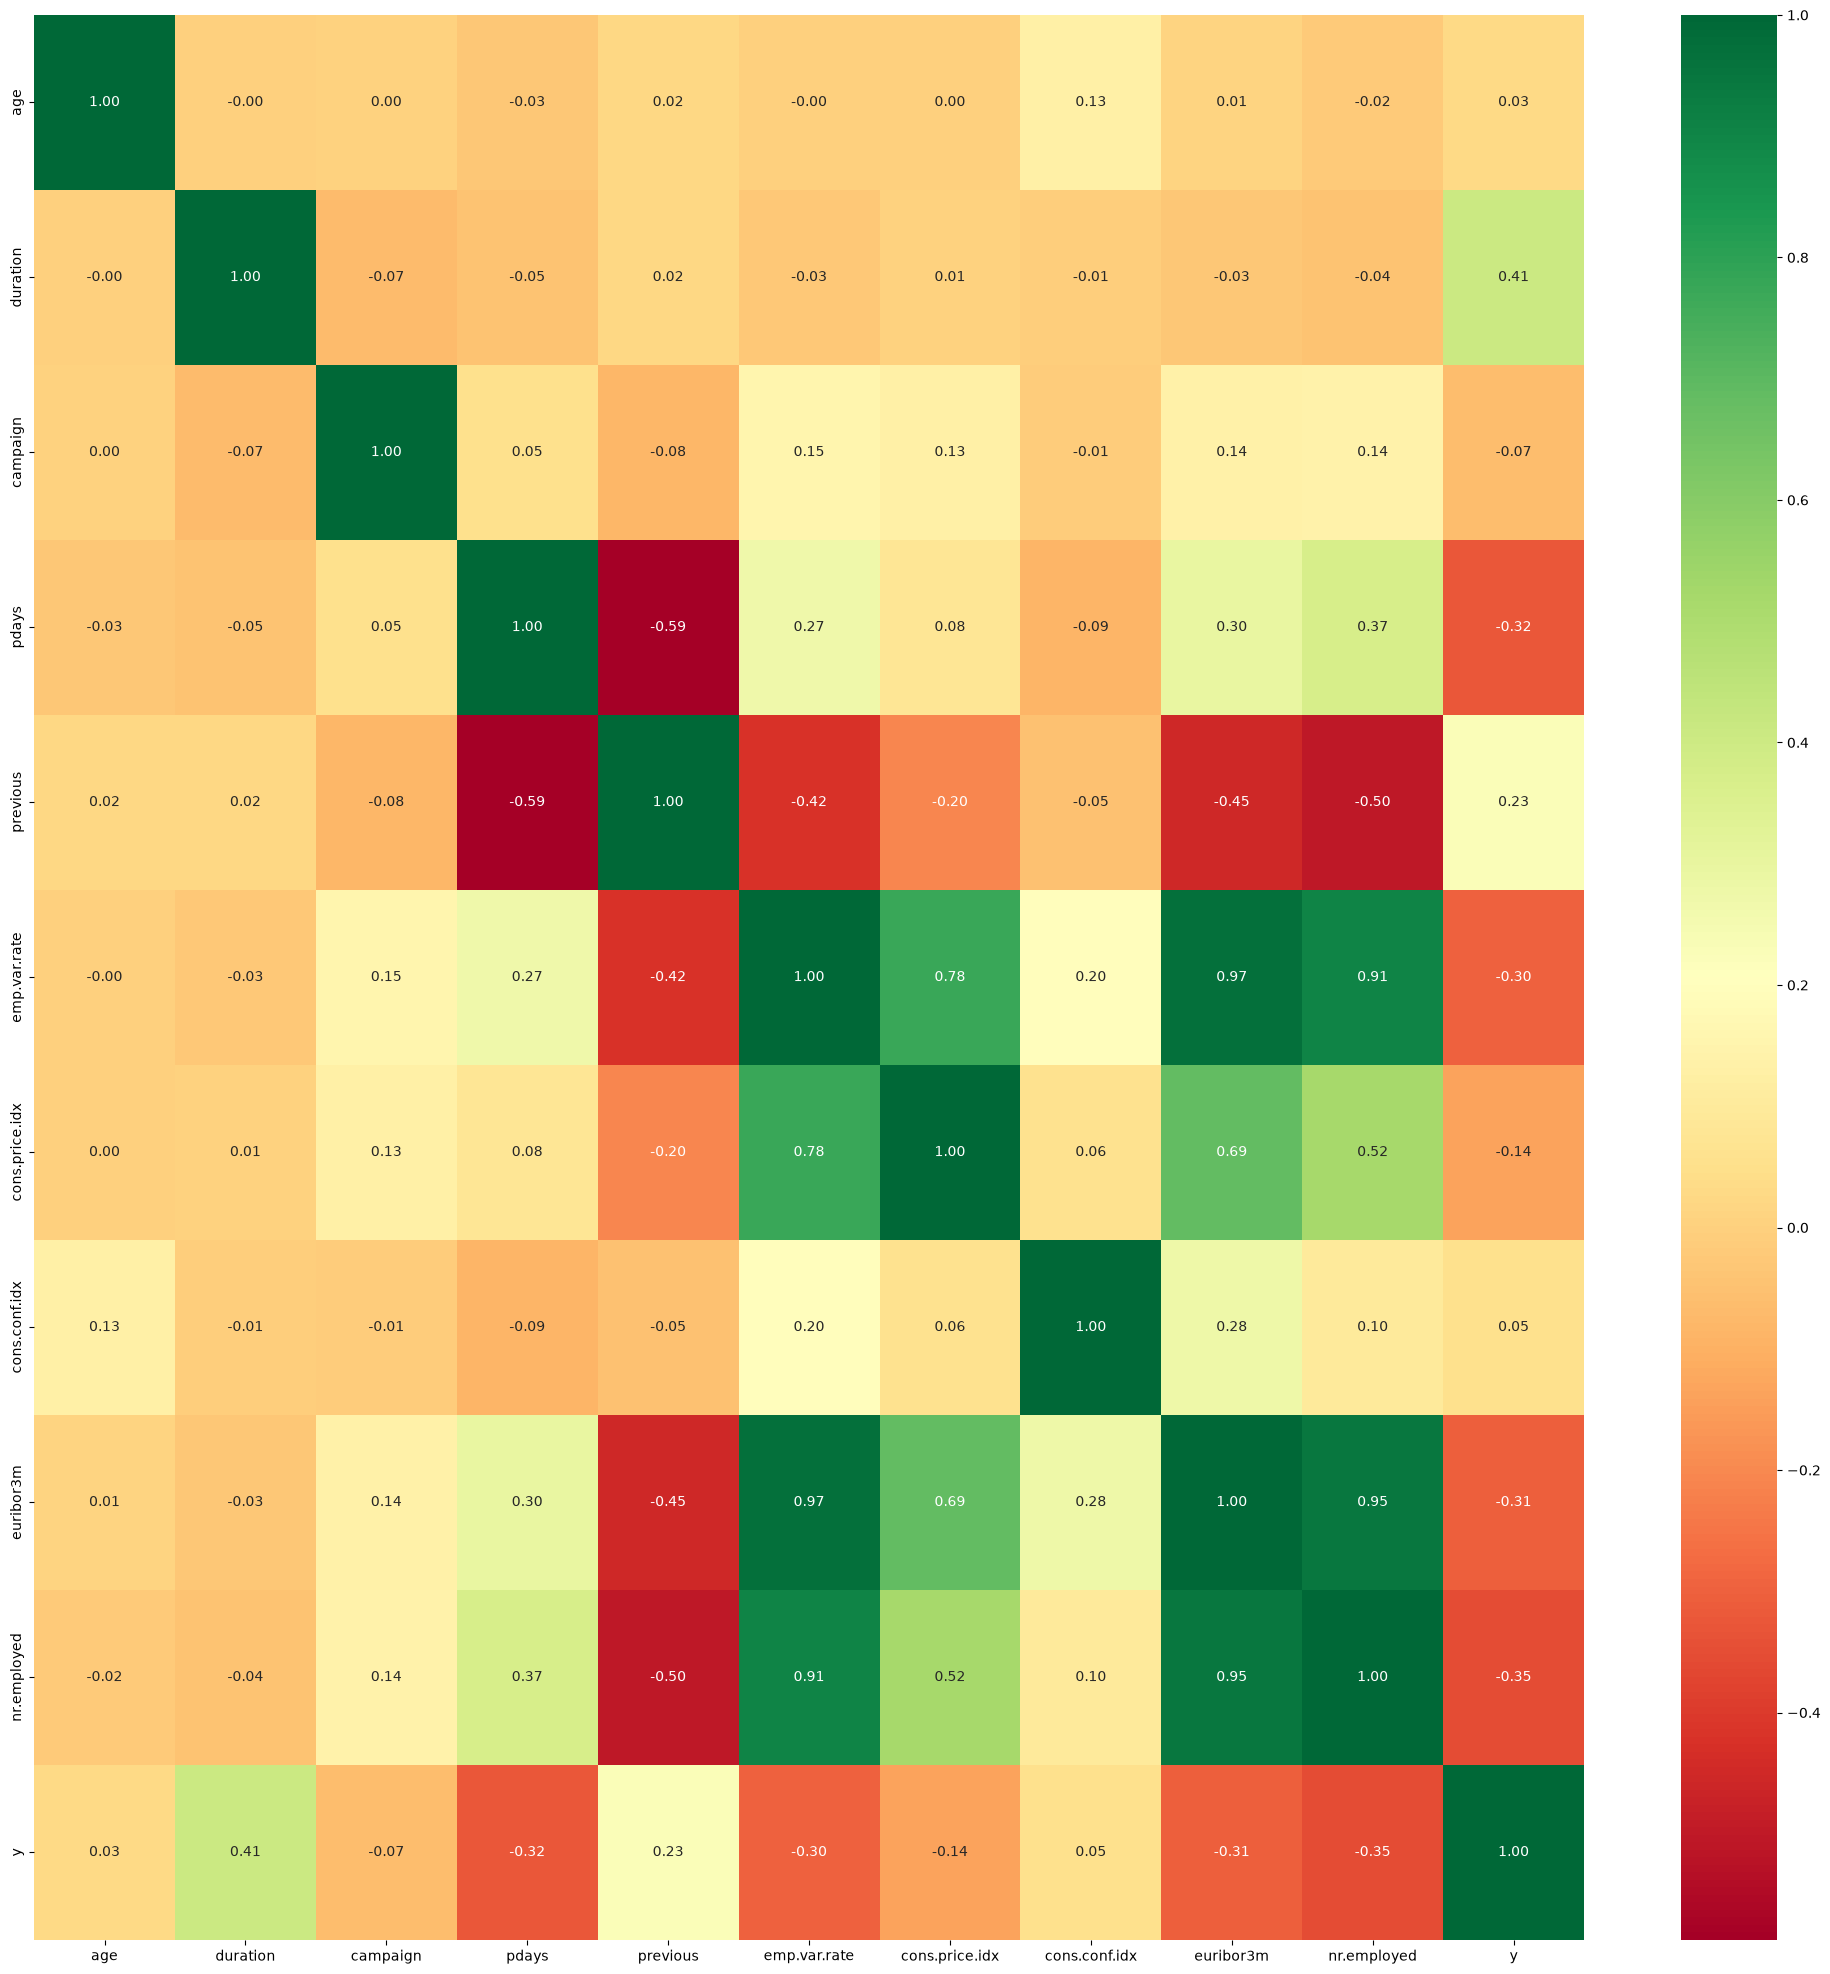

In [12]:
# Build correlation heatmap for numeric + target columns
corr_num = raw_df[[*numeric_cols, 'y']].corr()

plt.figure(figsize=(25, 25))
sns.heatmap(data=corr_num, annot=True, cmap="RdYlGn", cbar=True, fmt='.2f')
plt.show()

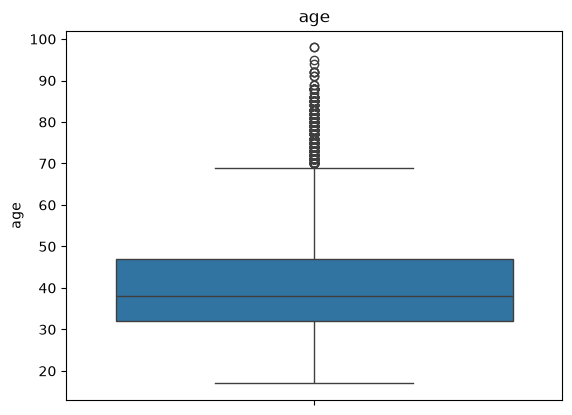

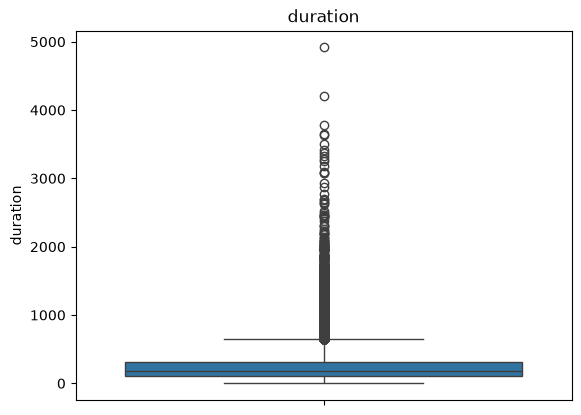

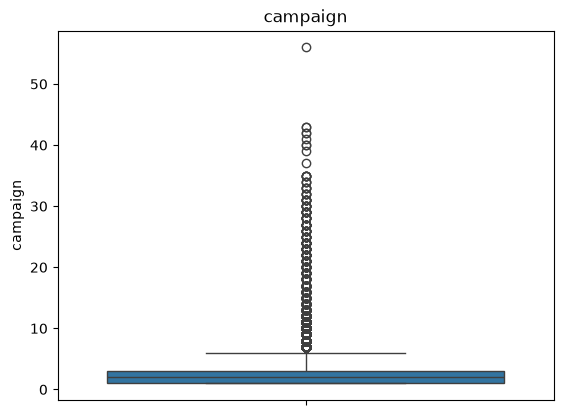

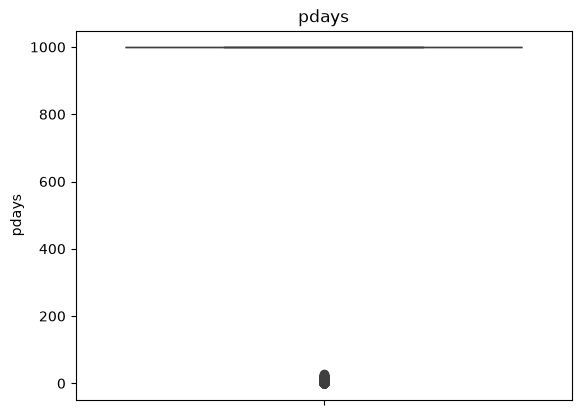

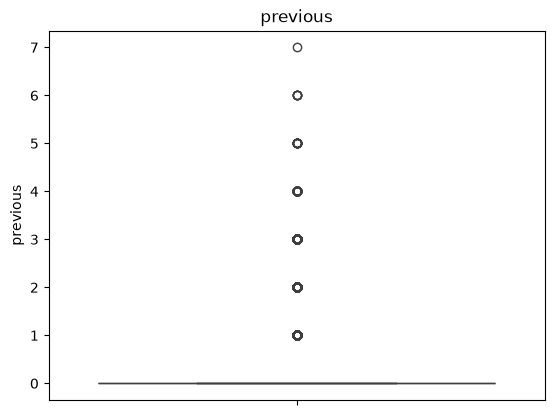

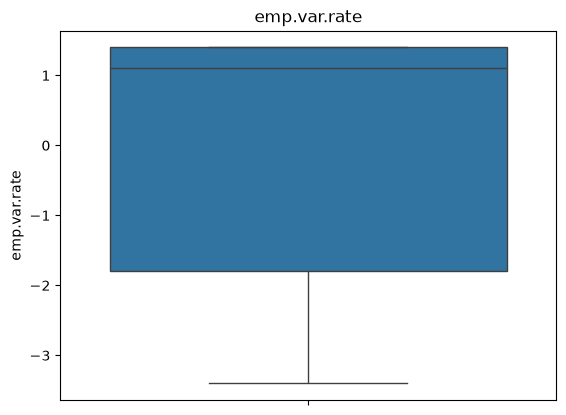

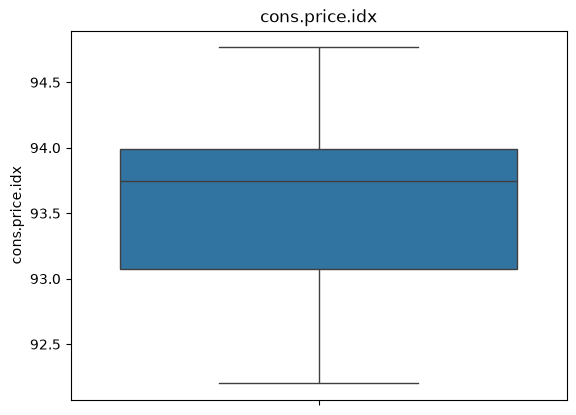

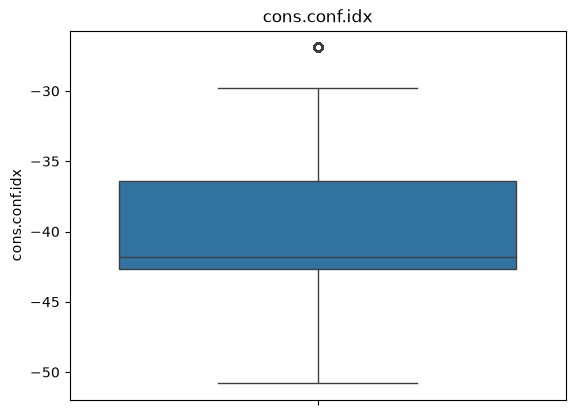

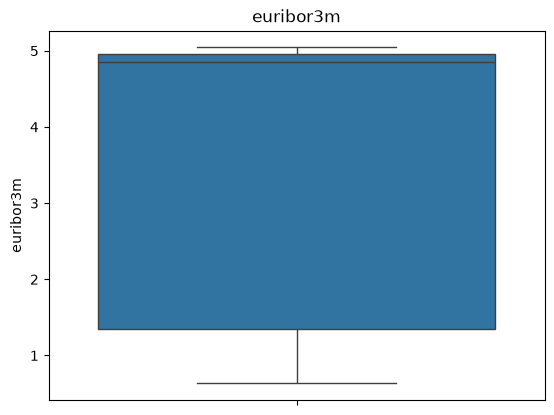

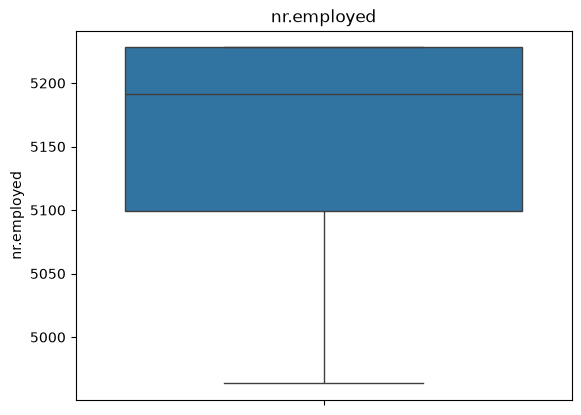

In [13]:
# Show boxplot for every numeric column
for col in numeric_cols:
    sns.boxplot(raw_df[col])
    plt.title(col)
    plt.show()

**Observations:**
- Columns `age`, `duration`, `campaign` have quite a lot of outliers.
- `pdays` non-outliers are concentated around 1000 and outliers are closer to 0. It is possible that there is some special value.
- `previous`non-outliers lie on 0 and outliers correspond to integer values from 1 to 7. Most of the data may have 0 value.
- Other numeric columns don't have outliers.

### `age` column

In [14]:
# Show statistical info for age column
raw_df['age'].describe()

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

In [15]:
# Check non-outliers bounds
print(get_regular_bounds(raw_df['age']))

{'min': np.float64(9.5), 'max': np.float64(69.5)}


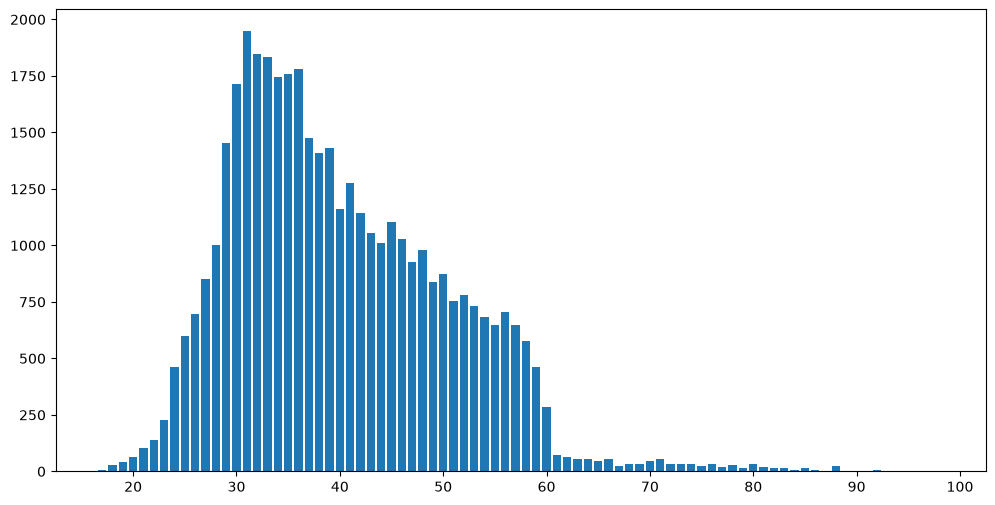

In [16]:
# Show ages distribution on a bar plot
age_value_counts = raw_df['age'].value_counts()
plt.figure(figsize=(12, 6))
plt.bar(age_value_counts.index, age_value_counts.values)
plt.show()

**Summary:**
- Non-outliers bounds tell us that ages 70 and higher are outliers. Though on bar plot we can see that there are few values higher than 60.
- It makes sense to create additional categorical feature with age ranges.

#### Create `age_ranges` column

In [17]:
# Define age ranges for new column
def age_cat(years):
    if years <= 20:
        return '0-20'
    elif years >= 21 and years <= 30:
        return '21-30'
    elif years >= 31 and years <= 35:
        return '31-35'
    elif years >= 36 and years <= 40:
        return '36-40'
    elif years >= 41 and years <= 50:
        return '41-50'
    elif years >= 51 and years <= 60:
        return '51-60'
    elif years >= 61:
        return '61+'

In [18]:
# Check age ranges on data
age_ranges = raw_df['age'].apply(age_cat)
age_ranges

0        51-60
1        51-60
2        36-40
3        36-40
4        51-60
         ...  
41183      61+
41184    41-50
41185    51-60
41186    41-50
41187      61+
Name: age, Length: 41188, dtype: object

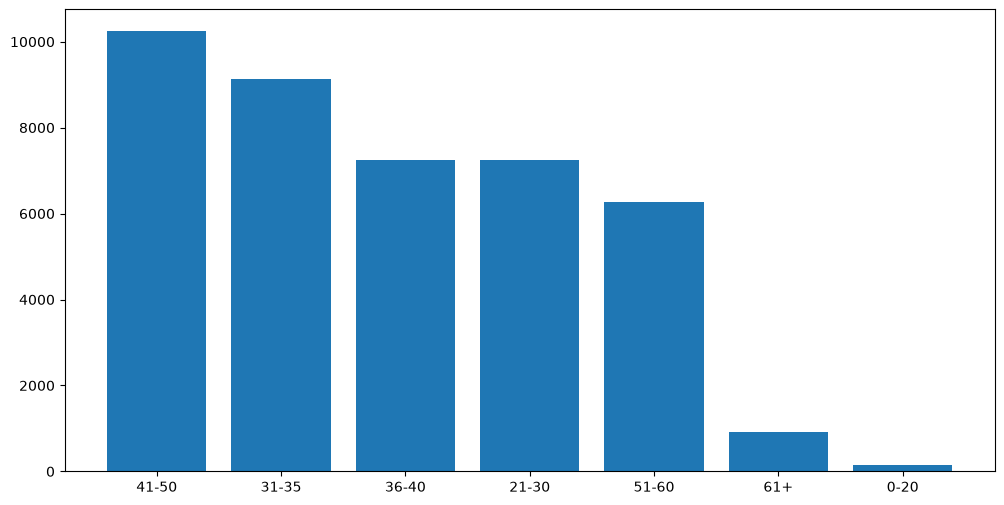

In [19]:
# Show age ranges distribution
age_cat_value_counts = age_ranges.value_counts()
plt.figure(figsize=(12, 6))
plt.bar(age_cat_value_counts.index.astype('str'), age_cat_value_counts.values)
plt.show()

### `duration` column

In [20]:
# Show statistics for duration column with high percentiles
raw_df['duration'].describe(percentiles=[0.75, 0.95, 0.99, 0.999])

count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
50%        180.000000
75%        319.000000
95%        752.650000
99%       1271.130000
99.9%     2175.585000
max       4918.000000
Name: duration, dtype: float64

In [21]:
# Check non-outliers bounds
print(get_regular_bounds(raw_df['duration']))

{'min': np.float64(-223.5), 'max': np.float64(644.5)}


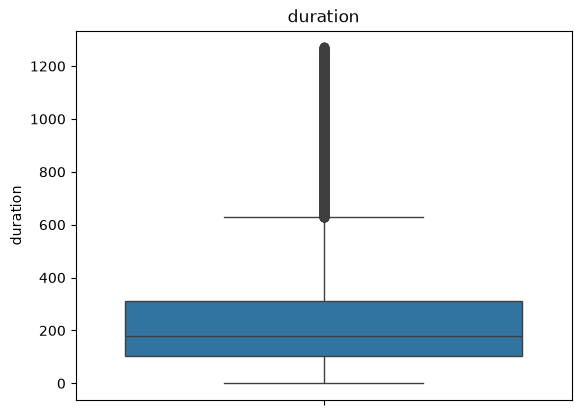

In [22]:
# Show boxplot for 99% percentile
train_duration_99_percentile = raw_df[raw_df['duration'] <= 1271]['duration']
sns.boxplot(train_duration_99_percentile)
plt.title('duration')
plt.show()

**Summary:**
- Values over 1271 for `duration` are outliers for sure.
- But we won't do anything with this column because it can be used for benchmark only.

### `pdays` column

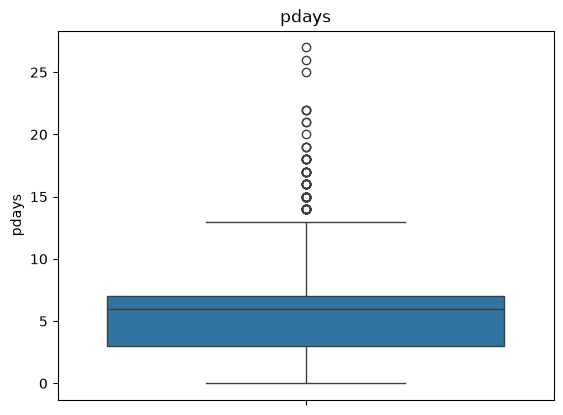

In [23]:
# In 'pdays' value 999 means no previous contact
# Show boxplot without it
pdays_no999 = raw_df[raw_df['pdays'] != 999]['pdays']
sns.boxplot(pdays_no999)
plt.title('pdays')
plt.show()

In [24]:
# Show value counts for pdays
raw_df['pdays'].value_counts()

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

In [25]:
# Check non-outliers bounds without special value
print(get_regular_bounds(pdays_no999))

{'min': np.float64(-3.0), 'max': np.float64(13.0)}


**Summary**
- Value 999 for `pdays` should be treated differently.
- Most of the data has this special value.
- Values >13 are outliers.
- The values apart from 999 are rare, we can create additional binary feature (999 vs other).

### `previous` column

In [26]:
# Show value counts for previous
raw_df['previous'].value_counts()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

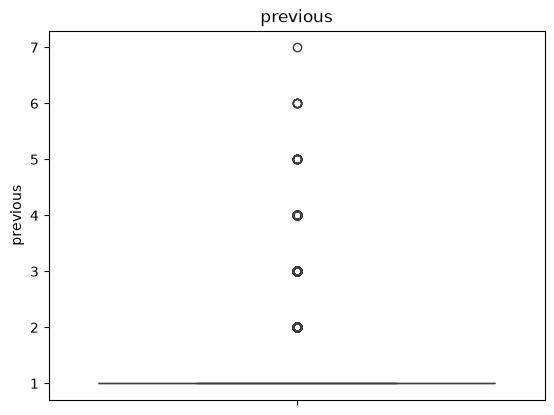

In [27]:
# In 'previous' most values are equal to 0 (no previous contact)
# Show boxplot without it
previous_no0 = raw_df[raw_df['previous'] != 0]['previous']
sns.boxplot(previous_no0)
plt.title('previous')
plt.show()

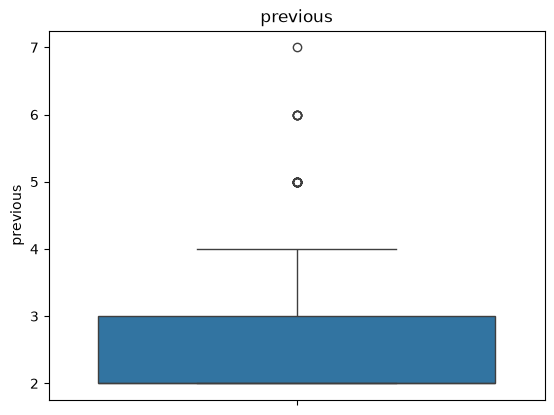

In [28]:
# Most values apart 0, are 1
# SHow barplot without both
previous_no01 = raw_df[(raw_df['previous'] != 0) & (raw_df['previous'] != 1)]['previous']
sns.boxplot(previous_no01)
plt.title('previous')
plt.show()

**Summary**
- Most of the instances have value 0 in `previous`.
- Most of the instances apart of 0 have value 1.
- It makes sense to create additional feature where values >1 will be merged into one.
- Value 0 for `previous` and value 999 for `pdays` might have the same meaning, but number of these values is different. Needs to be investigated.

#### Check `pdays` and `previous` discrepancy

In [29]:
# Check `previous` values !=0 in instances
# that have value 999 in `pdays`
raw_df[
    (raw_df['pdays'] == 999)
    & (raw_df['previous'] != 0)
    ]['previous'].value_counts()

previous
1    3696
2     349
3      50
4      12
5       2
6       1
Name: count, dtype: int64

**Summary**
- Looks like instances with `pdays`=999 and `previous`!=0 contain a mistake and should have different value in `pdays`.
- In the additional binary feature for `pdays` we can mark these instances as 'was contacted'.

### `campaign` column

In [30]:
# Check non-outliers bounds
print(get_regular_bounds(raw_df['campaign']))

{'min': np.float64(-2.0), 'max': np.float64(6.0)}


In [31]:
# Show value counts
raw_df['campaign'].value_counts()

campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
17       58
16       51
15       51
18       33
20       30
19       26
21       24
22       17
23       16
24       15
27       11
29       10
28        8
26        8
25        8
31        7
30        7
35        5
32        4
33        4
34        3
42        2
40        2
43        2
56        1
39        1
41        1
37        1
Name: count, dtype: int64

**Summary**
- Values >6 are outliers.
- Makes sense to put (some of) them into one category.

## Categorical columns

In [32]:
# Check numbers of unique values for categorical columns
raw_df[categorical_cols].nunique()

job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
dtype: int64

In [33]:
# Show value counts for every categorical column
for col in categorical_cols:
    print(raw_df[col].value_counts())
    print('\n')

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


contact
cellular     26144
telephone    15044
Name: coun

**Observations:**
- `job`, `marital`, `education`, `default`, `housing`, `loan` columns have 'unknown' value.
- There are only 3 instances with 'yes' value for `default`.
- `month` column doesn't have 'jan' and 'feb' values.
- `day_of_week` column doesn't have 'sat' and 'sun' values. Which is expected because banks usually don't work on week-ends.

### `default` column

In [34]:
# Show instances where 'default' column value is 'yes'
raw_df[raw_df['default'] == 'yes']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
21580,48,technician,married,professional.course,yes,no,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
21581,48,technician,married,professional.course,yes,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
24866,31,unemployed,married,high.school,yes,no,no,cellular,nov,tue,...,2,999,1,failure,-0.1,93.200,-42.0,4.153,5195.8,0


In [35]:
# Show some statistics for 'default' values based on target values
raw_df.groupby('default')['y'].agg(
    count='count',
    positive='sum',
    positive_rate='mean'
)

,count,positive,positive_rate
default,,,
no,32588,4197,0.12879
unknown,8597,443,0.05153
yes,3,0,0.00000


**Summary**
- There are only 3 instances with `default`='yes'. And all of them have target value of 0.
- Instances with 'unknown' value have mean target value closer to 0, but it is still fairly different from 0 target value for 'yes'.
- Leave this column as is.

### Correlation with target

In [36]:
# Encode categorical columns with OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(raw_df[categorical_cols])

encoded_cols = ohe.get_feature_names_out().tolist()

encoded_df = pd.DataFrame(
        ohe.transform(raw_df[categorical_cols]),
        columns=encoded_cols,
        index=raw_df.index
)
encoded_df

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
41184,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
41185,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
41186,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [37]:
# Check correlation with target for encoded columns
corr_cat = pd.concat([encoded_df, raw_df['y']], axis=1).corr()

corr_cat['y'].sort_values(ascending=False, key=abs)

y                                1.000000
poutcome_success                 0.316269
poutcome_nonexistent            -0.193507
contact_telephone               -0.144773
contact_cellular                 0.144773
month_mar                        0.144014
month_oct                        0.137366
month_sep                        0.126067
month_may                       -0.108271
default_no                       0.099344
default_unknown                 -0.099293
job_student                      0.093955
job_retired                      0.092221
month_dec                        0.079303
month_apr                        0.076136
job_blue-collar                 -0.074423
marital_single                   0.054133
education_university.degree      0.050364
education_basic.9y              -0.045135
marital_married                 -0.043398
job_services                    -0.032301
month_jul                       -0.032230
poutcome_failure                 0.031799
job_admin.                       0

In [38]:
# Check correlation with target for both numeric and encoded categorical columns
corr_all = pd.concat(
    [corr_num.drop('y', axis=0),
     corr_cat.drop('y', axis=0)],
    axis=0
)

corr_all['y'].sort_values(ascending=False, key=abs).head(20)

duration                0.405274
nr.employed            -0.354678
pdays                  -0.324914
poutcome_success        0.316269
euribor3m              -0.307771
emp.var.rate           -0.298334
previous                0.230181
poutcome_nonexistent   -0.193507
contact_telephone      -0.144773
contact_cellular        0.144773
month_mar               0.144014
month_oct               0.137366
cons.price.idx         -0.136211
month_sep               0.126067
month_may              -0.108271
default_no              0.099344
default_unknown        -0.099293
job_student             0.093955
job_retired             0.092221
month_dec               0.079303
Name: y, dtype: float64

**Observations**
- `duration` has the biggest correlation with target, but we won't use this feature for models training.
- Features that might have the biggest impact on target prediction in models:
    - `nr.employed` (socio-economic context: number of employees)
    - `pdays` (number of days from the last contact)
    - `poutcome_success` (successful outcome of the previous marketing campaign)
    - `euribor3m` (socio-economic context: euribor 3 month rate)
    - `emp.var.rate` (socio-economic context: employment variation rate)
- 3 out of 5 features which correlate the most with the target belong to socio-economic context.

# Metrics selection

In [39]:
# Show value counts for target column
raw_df['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

- Target `y` answers the question: has the client subscribed a term deposit?
- This variable is binary and has values: 'yes' (positive) and 'no' (negative).

Errors:
- False Positive (FP) - model predicted that client would subscribe, but he didn't.
- False Negative (FN) - model predicted that client would NOT subscribe, but he did.

FP means that bank employees would spend time for a client which won't buy a service. FN means that bank would give up on a client who whould buy a service. Both errors have their cost, but FN is a missed opportunity, so it's more important to focus on minimizing this kind of error.

Our target classes are imbalanced with much bigger number of the negative values than of the positive ones.

For models comparison we can use ROC AUC score and then find the best threshold value with Recall (to minimize FN) / F1 score (to balance between FN and FP).

In [40]:
# Re-read data from file
raw_df = pd.read_csv('bank-additional-full.csv', sep=';')

# Logistic Regression

## Default

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     31667
           1       0.23      0.67      0.34      1283

    accuracy                           0.90     32950
   macro avg       0.61      0.79      0.65     32950
weighted avg       0.96      0.90      0.92     32950



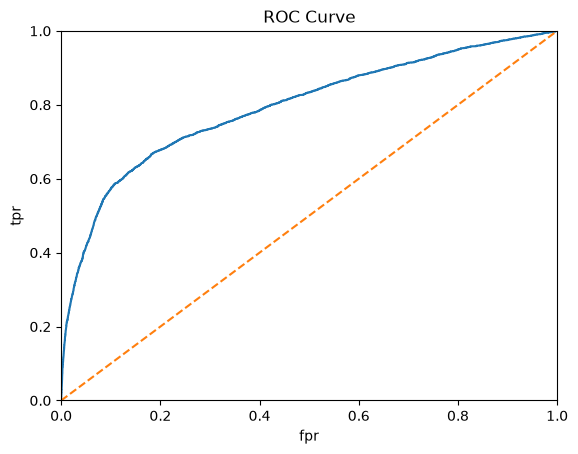

AUROC: 0.793763556438421

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7903
           1       0.22      0.62      0.33       335

    accuracy                           0.90      8238
   macro avg       0.60      0.76      0.64      8238
weighted avg       0.95      0.90      0.92      8238



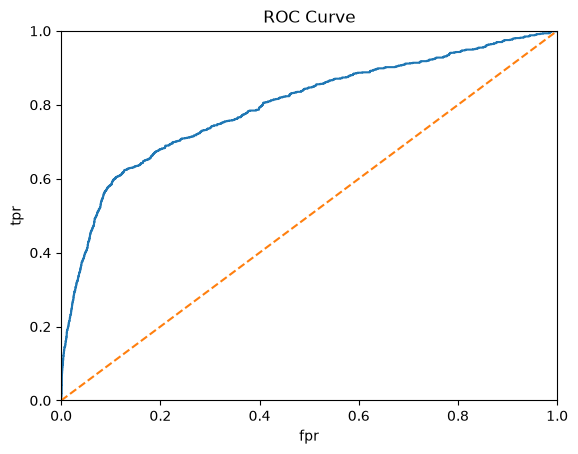

AUROC: 0.7952745412519459


In [41]:
# Transform, predict and show metrics
dp = DataProcessor(raw_df, ['y', 'duration'])
dp.transform_columns()
dp.predict_and_show_metrics(LogisticRegression(random_state=987))

In [42]:
# Check how many non-zero coefficients the model has
model_coefs = dp.classifier.coef_[0].tolist()
model_coefs_non_zero = [coef for coef in model_coefs if coef != 0.0]
print('Number of non-zero coefficients:', len(model_coefs_non_zero))

Number of non-zero coefficients: 72


## PolynomialFeatures

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     31609
           1       0.25      0.69      0.36      1341

    accuracy                           0.90     32950
   macro avg       0.62      0.80      0.66     32950
weighted avg       0.96      0.90      0.92     32950



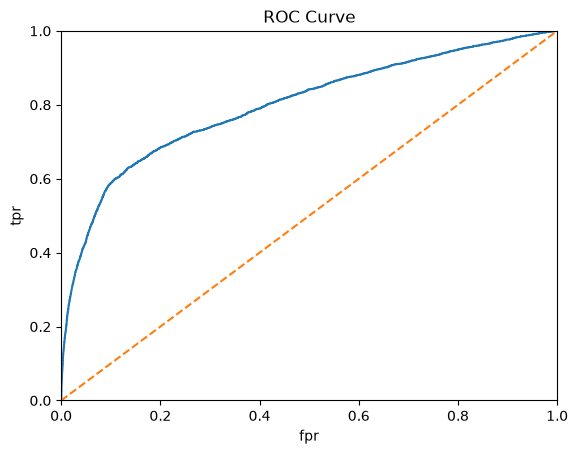

AUROC: 0.7989796478912069

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7922
           1       0.21      0.62      0.32       316

    accuracy                           0.90      8238
   macro avg       0.60      0.77      0.63      8238
weighted avg       0.95      0.90      0.92      8238



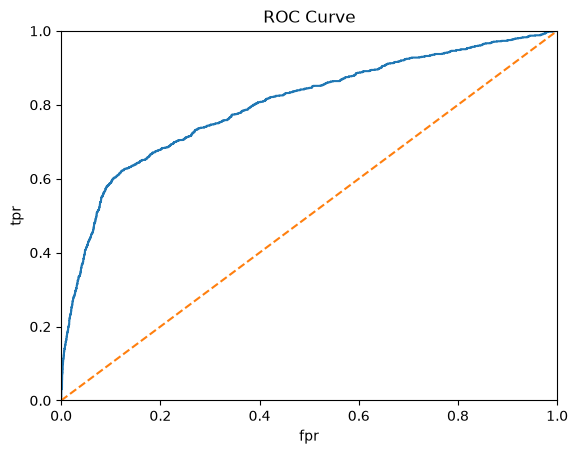

AUROC: 0.799224314826171


In [44]:
# Transform, predict and show metrics
dp_pol = DataProcessor(raw_df, ['y', 'duration'])

num_preprocessor = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial', PolynomialFeatures(degree=5))
])
dp_pol.transform_columns(num_preprocessor=num_preprocessor)

dp_pol.predict_and_show_metrics(LogisticRegression(random_state=987, max_iter=200))

In [45]:
# Number of features in the model
dp_pol.classifier.n_features_in_

3065

In [46]:
# Check number of non-zero coefficients in the model
model_coefs = dp_pol.classifier.coef_[0].tolist()
model_coefs_non_zero = [coef for coef in model_coefs if coef != 0.0]
print('Number of non-zero coefficients:', len(model_coefs_non_zero))

Number of non-zero coefficients: 3065


## TomekLinks

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     30543
           1       0.26      0.70      0.38      1392

    accuracy                           0.90     31935
   macro avg       0.62      0.80      0.66     31935
weighted avg       0.95      0.90      0.92     31935



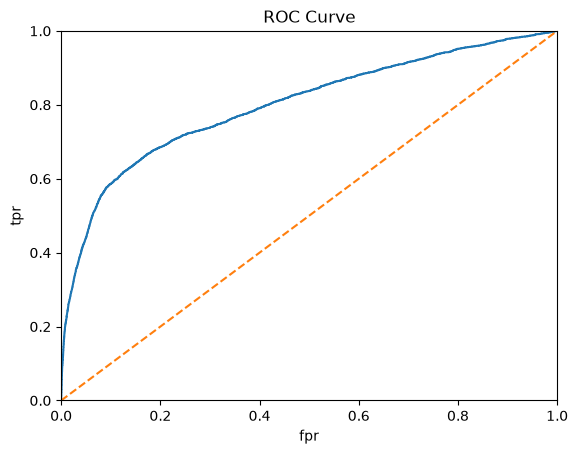

AUROC: 0.7997004947587991

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7621
           1       0.25      0.65      0.36       360

    accuracy                           0.90      7981
   macro avg       0.62      0.78      0.65      7981
weighted avg       0.95      0.90      0.92      7981



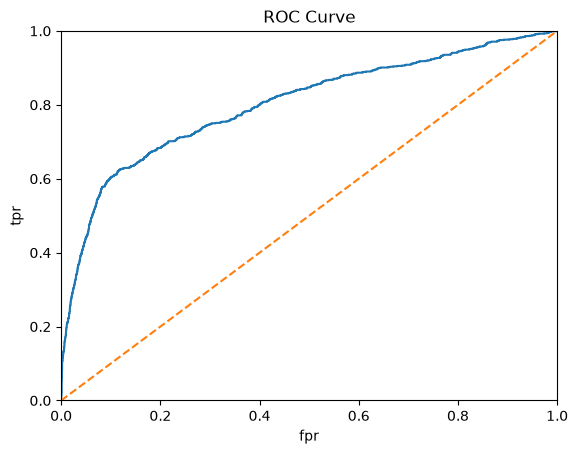

AUROC: 0.8010092611605724


In [83]:
# Transform, resample, predict and show metrics
dp_tomek = DataProcessor(raw_df, ['y', 'duration'])
dp_tomek.transform_columns()

sampler = TomekLinks()
dp_tomek.X_train, dp_tomek.y_train = sampler.fit_resample(dp_tomek.X_train, dp_tomek.y_train)
dp_tomek.X_test, dp_tomek.y_test = sampler.fit_resample(dp_tomek.X_test, dp_tomek.y_test)

dp_tomek.predict_and_show_metrics(LogisticRegression(random_state=987))

## Liblinear solver + L1 regularization

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     31652
           1       0.23      0.66      0.34      1298

    accuracy                           0.90     32950
   macro avg       0.61      0.79      0.65     32950
weighted avg       0.96      0.90      0.92     32950



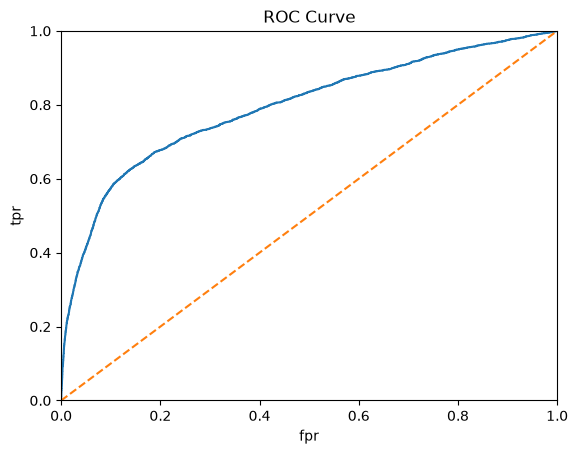

AUROC: 0.7942319736316814

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7898
           1       0.23      0.62      0.33       340

    accuracy                           0.90      8238
   macro avg       0.60      0.76      0.64      8238
weighted avg       0.95      0.90      0.92      8238



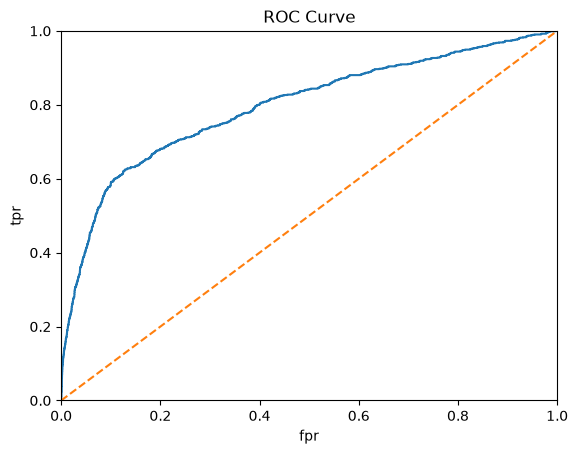

AUROC: 0.7953932821123639


In [50]:
# Transform, predict and show metrics
dp_lib_l1 = DataProcessor(raw_df, ['y', 'duration'])
dp_lib_l1.transform_columns()
dp_lib_l1.predict_and_show_metrics(LogisticRegression(
    random_state=987,
    solver='liblinear',
    l1_ratio=1
))

In [51]:
model_coefs = dp_lib_l1.classifier.coef_[0].tolist()
model_coefs_non_zero = [coef for coef in model_coefs if coef != 0.0]
print('Number of non-zero coefficients:', len(model_coefs_non_zero))

Number of non-zero coefficients: 55


## PolynomialFeatures + Liblinear + L1

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     31645
           1       0.24      0.68      0.36      1305

    accuracy                           0.90     32950
   macro avg       0.61      0.80      0.65     32950
weighted avg       0.96      0.90      0.92     32950



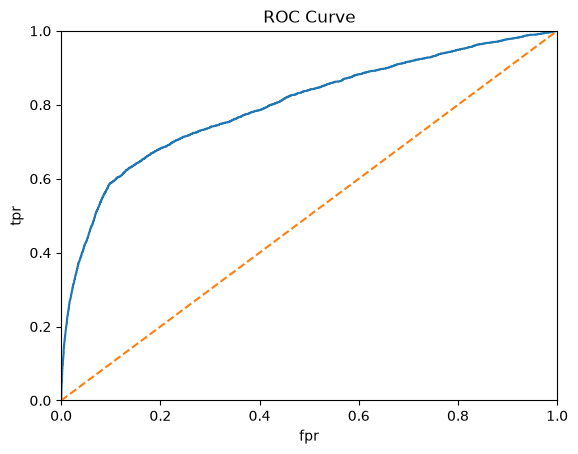

AUROC: 0.7977466228777028

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7920
           1       0.22      0.64      0.33       318

    accuracy                           0.90      8238
   macro avg       0.60      0.77      0.64      8238
weighted avg       0.95      0.90      0.92      8238



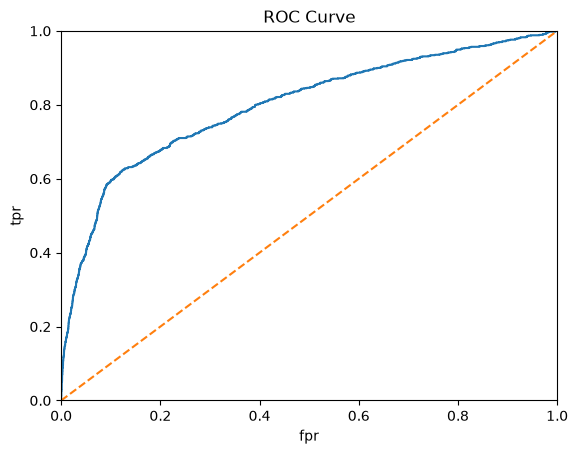

AUROC: 0.7984419960847209


In [53]:
# Transform, predict and show metrics
dp_pol_lib_l1 = DataProcessor(raw_df, ['y', 'duration'])

num_preprocessor = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('polynomial', PolynomialFeatures(degree=5))
])
dp_pol_lib_l1.transform_columns(num_preprocessor=num_preprocessor)

dp_pol_lib_l1.predict_and_show_metrics(LogisticRegression(
    random_state=987,
    max_iter=200,
    solver='liblinear',
    l1_ratio=1
))

In [54]:
# Number of features in the model
dp_pol_lib_l1.classifier.n_features_in_

3065

In [55]:
# Check number of non-zero coefficients in the model
model_coefs = dp_pol_lib_l1.classifier.coef_[0].tolist()
model_coefs_non_zero = [coef for coef in model_coefs if coef != 0.0]
print('Number of non-zero coefficients:', len(model_coefs_non_zero))

Number of non-zero coefficients: 189


# kNN

## Default

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     31302
           1       0.33      0.74      0.46      1648

    accuracy                           0.91     32950
   macro avg       0.66      0.83      0.70     32950
weighted avg       0.95      0.91      0.93     32950



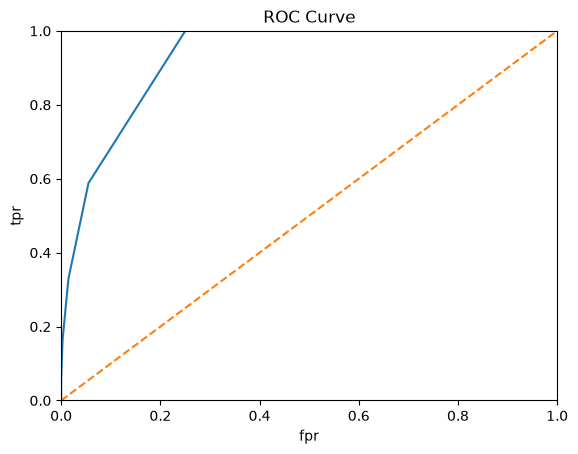

AUROC: 0.9265013868421705

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7878
           1       0.21      0.54      0.30       360

    accuracy                           0.89      8238
   macro avg       0.59      0.73      0.62      8238
weighted avg       0.94      0.89      0.91      8238



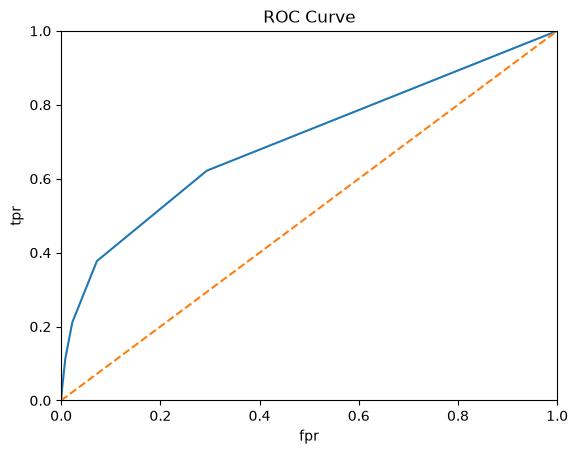

AUROC: 0.7008706188971179


In [56]:
# Transform, predict and show metrics
dp_knn = DataProcessor(raw_df, ['y', 'duration'])
dp_knn.transform_columns()
dp_knn.predict_and_show_metrics(KNeighborsClassifier())

## RandomSearchCV

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.90      0.95     32195
           1       0.15      0.75      0.25       755

    accuracy                           0.90     32950
   macro avg       0.57      0.83      0.60     32950
weighted avg       0.97      0.90      0.93     32950



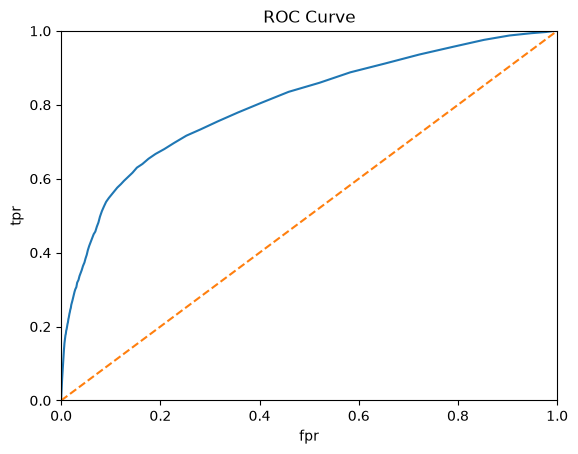

AUROC: 0.8006569035616734

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.99      0.90      0.95      8045
           1       0.15      0.73      0.25       193

    accuracy                           0.90      8238
   macro avg       0.57      0.81      0.60      8238
weighted avg       0.97      0.90      0.93      8238



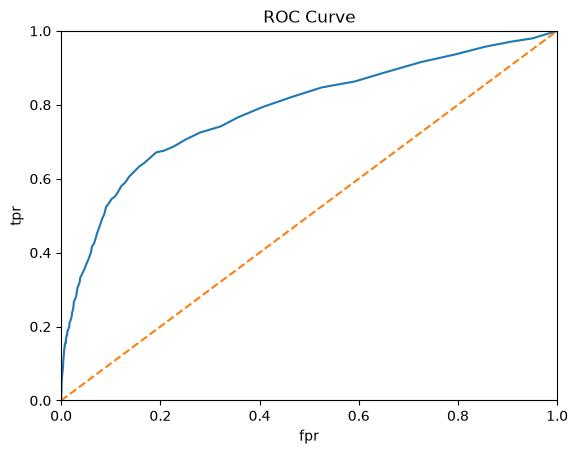

AUROC: 0.7847074891504315


In [57]:
# Transform, search for params, predict and show metrics
dp_knn_rand = DataProcessor(raw_df, ['y', 'duration'])
dp_knn_rand.transform_columns()

param_grid = {
    'weights': ['uniform', 'distance'],
    'n_neighbors': range(2, 201)
}

selector = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_grid,
    scoring='roc_auc',
    n_iter=50,
    random_state=987
)

dp_knn_rand.predict_and_show_metrics(selector)

In [58]:
# Show the best found parameters
dp_knn_rand.classifier.best_params_

{'weights': 'uniform', 'n_neighbors': 199}

# Decision Tree

## Default

TRAIN
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     29397
           1       0.96      1.00      0.98      3553

    accuracy                           0.99     32950
   macro avg       0.98      1.00      0.99     32950
weighted avg       1.00      0.99      0.99     32950



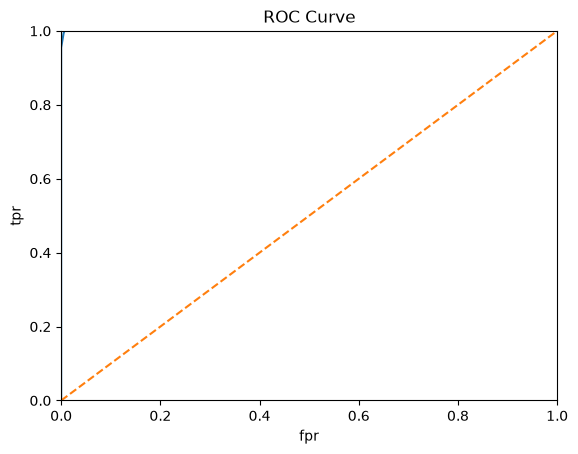

AUROC: 0.9998685127747664

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      7219
           1       0.35      0.32      0.33      1019

    accuracy                           0.84      8238
   macro avg       0.63      0.62      0.62      8238
weighted avg       0.84      0.84      0.84      8238



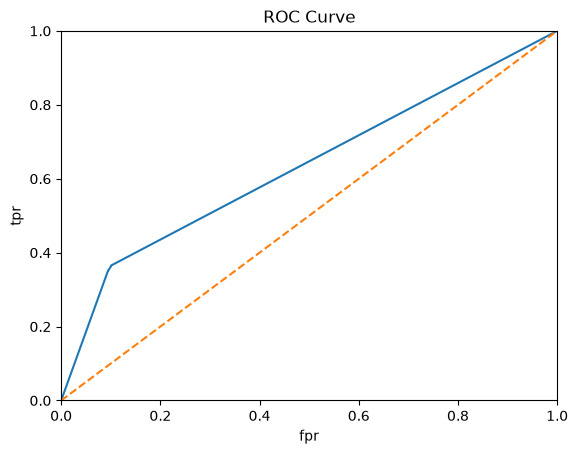

AUROC: 0.6326789441718949


In [59]:
# Transform, predict and show metrics
dp_tree = DataProcessor(raw_df, ['y', 'duration'])
dp_tree.transform_columns(num_preprocessor='passthrough')
dp_tree.predict_and_show_metrics(DecisionTreeClassifier(random_state=987))

## RandomSearchCV

TRAIN
              precision    recall  f1-score   support

           0       0.98      0.91      0.95     31489
           1       0.26      0.67      0.38      1461

    accuracy                           0.90     32950
   macro avg       0.62      0.79      0.66     32950
weighted avg       0.95      0.90      0.92     32950



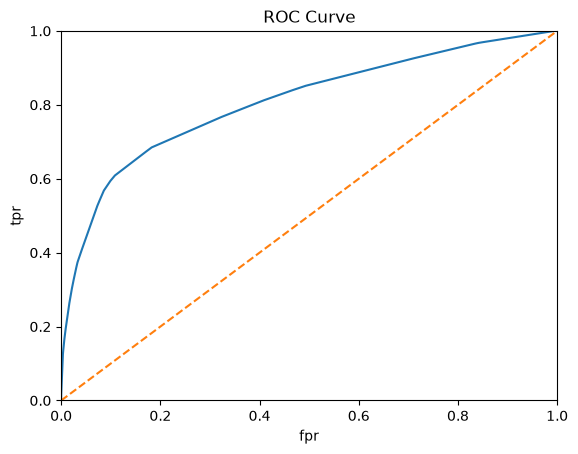

AUROC: 0.8075804170543884

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      7874
           1       0.25      0.65      0.36       364

    accuracy                           0.90      8238
   macro avg       0.62      0.78      0.65      8238
weighted avg       0.95      0.90      0.92      8238



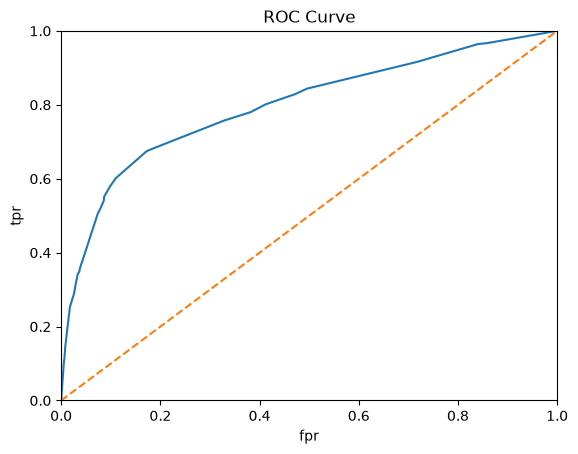

AUROC: 0.7969560032312845


In [60]:
# Transform, predict and show metrics
dp_tree_rand = DataProcessor(raw_df, ['y', 'duration'])
dp_tree_rand.transform_columns(num_preprocessor='passthrough')

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': range(1, 50),
    'max_leaf_nodes': range(2, 100),
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 20)
}

selector_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=987),
    param_distributions=param_grid_dt,
    scoring='roc_auc',
    n_iter=100,
    random_state=987
)

dp_tree_rand.predict_and_show_metrics(selector_dt)

In [61]:
dp_tree_rand.classifier.best_params_

{'splitter': 'best',
 'min_samples_split': 7,
 'min_samples_leaf': 5,
 'max_leaf_nodes': 36,
 'max_depth': 33,
 'criterion': 'entropy'}

# XGBClassifier

## Default

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     31041
           1       0.45      0.87      0.59      1909

    accuracy                           0.93     32950
   macro avg       0.72      0.90      0.78     32950
weighted avg       0.96      0.93      0.94     32950



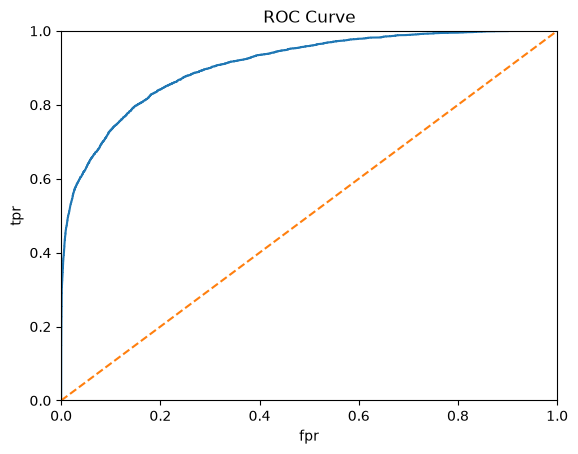

AUROC: 0.9082313886952738

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      7800
           1       0.27      0.57      0.37       438

    accuracy                           0.89      8238
   macro avg       0.62      0.74      0.65      8238
weighted avg       0.94      0.89      0.91      8238



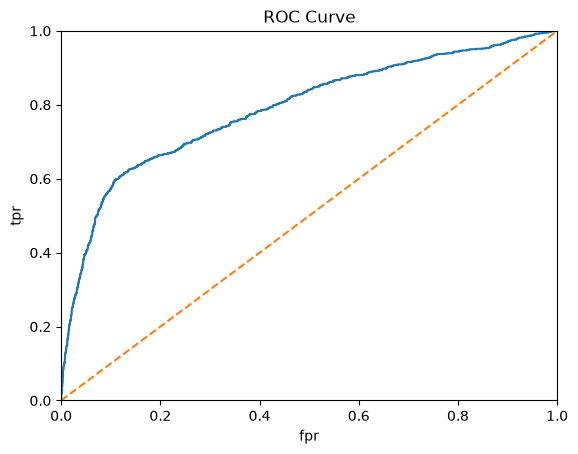

AUROC: 0.7891344373555356


In [62]:
# Transform, predict and show metrics
dp_xgb = DataProcessor(raw_df, ['y', 'duration'])
dp_xgb.transform_columns(num_preprocessor='passthrough')
dp_xgb.predict_and_show_metrics(XGBClassifier(
    random_state=987,
    eval_metric=auc
))

## With RandomSearchCV

TRAIN
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     31410
           1       0.30      0.71      0.42      1540

    accuracy                           0.91     32950
   macro avg       0.64      0.82      0.68     32950
weighted avg       0.95      0.91      0.92     32950



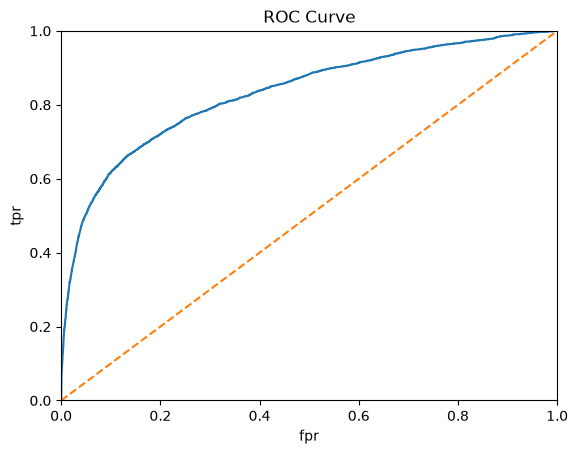

AUROC: 0.8323088699740655

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7862
           1       0.24      0.60      0.35       376

    accuracy                           0.90      8238
   macro avg       0.61      0.76      0.65      8238
weighted avg       0.95      0.90      0.92      8238



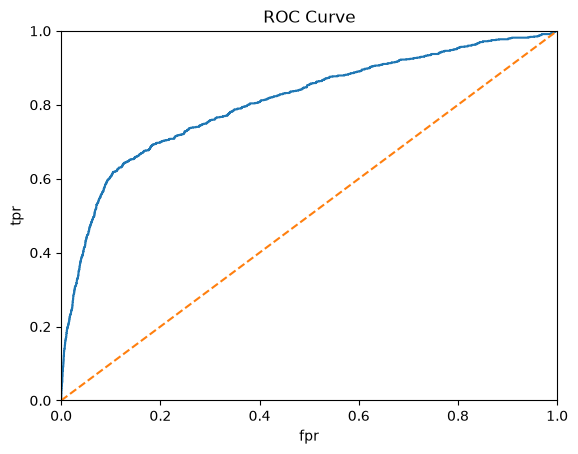

AUROC: 0.8073937007641869


In [69]:
# Transform columns
dp_xgb_rand = DataProcessor(raw_df, ['y', 'duration'])
dp_xgb_rand.transform_columns(num_preprocessor='passthrough')

# Hyperparameters grid
param_grid_xgb = {
    'n_estimators': range(100, 501, 5),
    'max_depth': range(2, 21),
    'min_child_weight': range(1, 21),
    'learning_rate': np.arange(0.03, 0.3, 0.01),
    'subsample': np.arange(0.7, 1.0, 0.01),
    'colsample_bytree': np.arange(0.7, 1.0, 0.01),
    'gamma': np.arange(0.05, 10, 0.01),
    'reg_alpha': np.arange(0.03, 10, 0.01),
    'reg_lambda': np.arange(0.1, 10, 0.1),
}

# Define selector
selector_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=987,
        eval_metric=auc
    ),
    param_distributions=param_grid_xgb,
    scoring='roc_auc',
    n_iter=200,
    random_state=987
)

# Predict and show metrics
dp_xgb_rand.predict_and_show_metrics(selector_xgb)

## With Hyperopt

In [65]:
# Transform columns
dp_xgb_hyper = DataProcessor(raw_df, ['y', 'duration'])
dp_xgb_hyper.transform_columns(num_preprocessor='passthrough')

# Hyperparameters space
xgb_space = {
    'max_depth': hp.uniformint('max_depth', 2, 20),
    'min_child_weight': hp.loguniform('min_child_weight', np.log(1), np.log(20)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.03), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'gamma': hp.loguniform('gamma', np.log(0.05), np.log(10)),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.03), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(0.1), np.log(10))
}

# Search for the best parameters
best_xgb = DataProcessor.search_best_params(
    'xgb', xgb_space,
    dp_xgb_hyper.X_train, dp_xgb_hyper.y_train,
    dp_xgb_hyper.X_test, dp_xgb_hyper.y_test
)
best_xgb

100%|██████████| 200/200 [02:03<00:00,  1.62trial/s, best loss: -0.8092971661399122]


{'colsample_bytree': 0.8887299444719118,
 'gamma': 0.952065069919978,
 'learning_rate': 0.06499436433395438,
 'max_depth': 13,
 'min_child_weight': 11.830778928961239,
 'reg_alpha': 4.91197378653593,
 'reg_lambda': 2.7196257404488615,
 'subsample': 0.8243651542681284}

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     31505
           1       0.28      0.71      0.40      1445

    accuracy                           0.91     32950
   macro avg       0.63      0.81      0.67     32950
weighted avg       0.95      0.91      0.92     32950



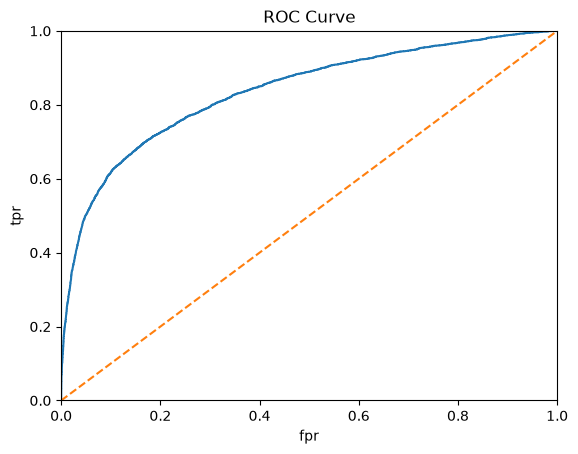

AUROC: 0.8361118135188382

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7887
           1       0.24      0.63      0.35       351

    accuracy                           0.90      8238
   macro avg       0.61      0.77      0.65      8238
weighted avg       0.95      0.90      0.92      8238



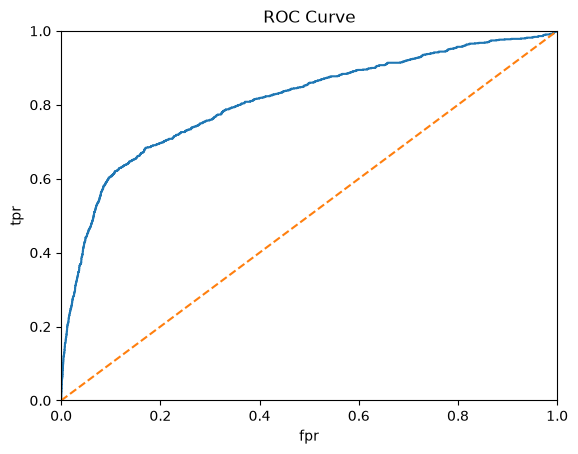

AUROC: 0.8092971661399122


In [67]:
# Create and use classifier with optimized parameters
best_xgb_clf = XGBClassifier(
    max_depth=best_xgb['max_depth'],
    min_child_weight=best_xgb['min_child_weight'],
    learning_rate=best_xgb['learning_rate'],
    subsample=best_xgb['subsample'],
    colsample_bytree=best_xgb['colsample_bytree'],
    gamma=best_xgb['gamma'],
    reg_alpha=best_xgb['reg_alpha'],
    reg_lambda=best_xgb['reg_lambda'],
    n_estimators=1000,
    early_stopping_rounds=100,
    random_state=987
)

# Predict and show metrics
dp_xgb_hyper.predict_and_show_metrics(
    best_xgb_clf,
    eval_set=[(dp_xgb_hyper.X_test, dp_xgb_hyper.y_test)],
    verbose=False
)

# LGBMClassifier

## Default

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     31338
           1       0.34      0.78      0.47      1612

    accuracy                           0.91     32950
   macro avg       0.66      0.85      0.71     32950
weighted avg       0.96      0.91      0.93     32950



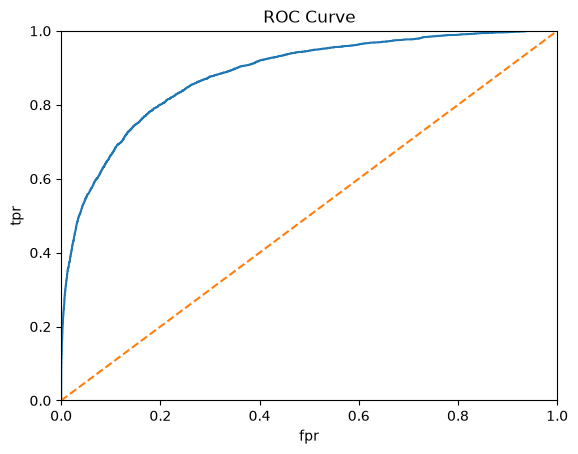

AUROC: 0.8826281893794918

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      7852
           1       0.26      0.63      0.37       386

    accuracy                           0.90      8238
   macro avg       0.62      0.77      0.66      8238
weighted avg       0.95      0.90      0.92      8238



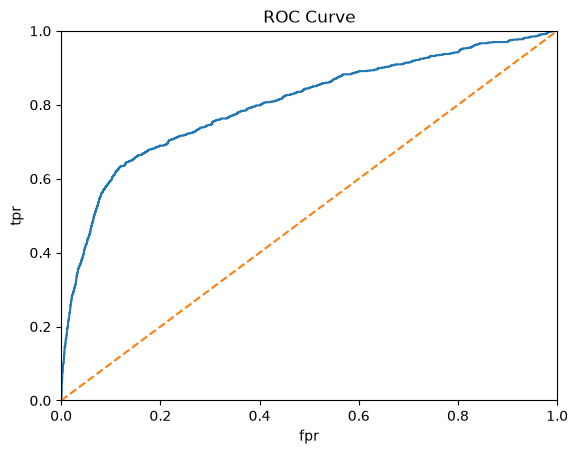

AUROC: 0.8016707008585311


In [68]:
# Transform, predict and show metrics
dp_lgb = DataProcessor(raw_df, ['y', 'duration'])
dp_lgb.transform_columns(num_preprocessor='passthrough')
dp_lgb.predict_and_show_metrics(LGBMClassifier(
    random_state=987,
    verbose=-1
))

## With RandomSearchCV

TRAIN
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     31444
           1       0.29      0.72      0.41      1506

    accuracy                           0.91     32950
   macro avg       0.64      0.82      0.68     32950
weighted avg       0.95      0.91      0.93     32950



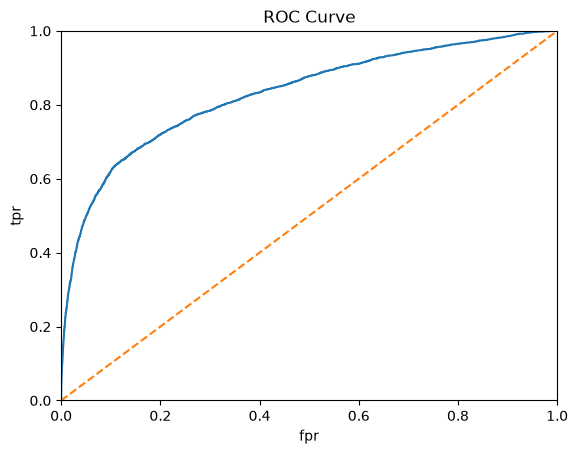

AUROC: 0.8298619204002938

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      7875
           1       0.25      0.64      0.36       363

    accuracy                           0.90      8238
   macro avg       0.62      0.78      0.65      8238
weighted avg       0.95      0.90      0.92      8238



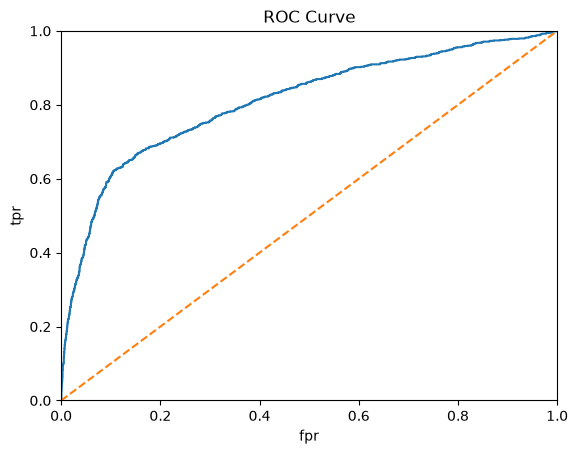

AUROC: 0.8100010613708195


In [72]:
# Transform columns
dp_lgb_rand = DataProcessor(raw_df, ['y', 'duration'])
dp_lgb_rand.transform_columns(num_preprocessor='passthrough')

# Hyperparameters grid
param_grid_lgb = {
    'n_estimators': range(100, 501, 5),
    'max_depth': range(2, 21),
    'min_child_samples': range(5, 51),
    'num_leaves': range(10, 101),
    'min_split_gain': np.arange(0.01, 1, 0.01),
    'learning_rate': np.arange(0.01, 0.3, 0.01),
    'subsample': np.arange(0.5, 0.99, 0.02),
    'colsample_bytree': np.arange(0.7, 0.99, 0.01),
    'reg_alpha': np.arange(0.1, 10, 0.1),
    'reg_lambda': np.arange(0.1, 10, 0.1),
}

# Define selector
selector_lgb = RandomizedSearchCV(
    estimator=LGBMClassifier(
        random_state=987,
        verbose=-1
    ),
    param_distributions=param_grid_lgb,
    scoring='roc_auc',
    n_iter=200,
    random_state=987
)

# Predict and show metrics
dp_lgb_rand.predict_and_show_metrics(selector_lgb)

## With Hyperopt

In [75]:
# Transform, predict and show metrics
dp_lgb_hyper = DataProcessor(raw_df, ['y', 'duration'])
dp_lgb_hyper.transform_columns(num_preprocessor='passthrough')

# Hyperparameters space
lgb_space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'min_child_samples': scope.int(hp.loguniform('min_child_samples', np.log(5), np.log(50))),
    'num_leaves': scope.int(hp.loguniform('num_leaves', np.log(10), np.log(100))),
    'max_depth': hp.uniformint('max_depth', 2, 20),
    'min_split_gain': hp.loguniform('min_split_gain', np.log(0.01), np.log(1)),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(0.1), np.log(10))
}

# Search for the best parameters
best_lgb = DataProcessor.search_best_params(
    'lgb', lgb_space,
    dp_lgb_hyper.X_train, dp_lgb_hyper.y_train,
    dp_lgb_hyper.X_test, dp_lgb_hyper.y_test
)
best_lgb

100%|██████████| 200/200 [02:51<00:00,  1.17trial/s, best loss: -0.811740014269541] 


{'colsample_bytree': 0.8447338076361095,
 'learning_rate': 0.26178001299485343,
 'max_depth': 13,
 'min_child_samples': 15,
 'min_split_gain': 0.4343688422225918,
 'num_leaves': 22,
 'reg_alpha': 0.006577423731648732,
 'reg_lambda': 4.1573552233584445,
 'subsample': 0.8685652400244539}

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[15]	valid_0's binary_logloss: 0.270505
TRAIN
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     31497
           1       0.27      0.70      0.39      1453

    accuracy                           0.91     32950
   macro avg       0.63      0.81      0.67     32950
weighted avg       0.95      0.91      0.92     32950



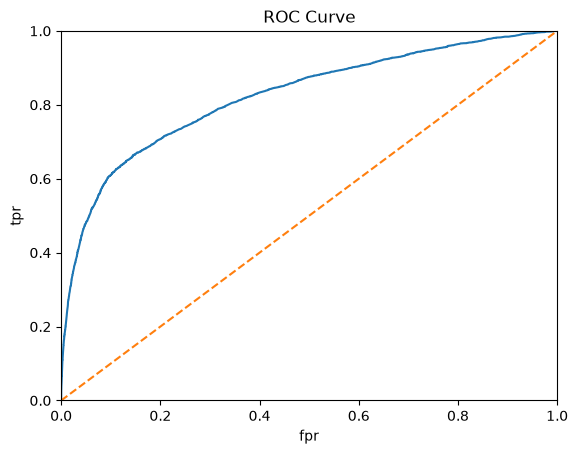

AUROC: 0.8234598087396894

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      7893
           1       0.24      0.64      0.35       345

    accuracy                           0.90      8238
   macro avg       0.61      0.77      0.65      8238
weighted avg       0.95      0.90      0.92      8238



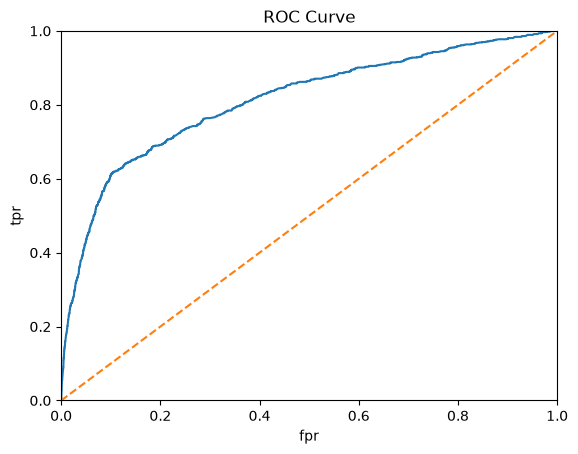

AUROC: 0.811740014269541


In [77]:
# Create and use classifier with optimized parameters
best_lgb_clf = LGBMClassifier(
    learning_rate=best_lgb['learning_rate'],
    min_child_samples=best_lgb['min_child_samples'],
    num_leaves=best_lgb['num_leaves'],
    max_depth=best_lgb['max_depth'],
    min_split_gain=best_lgb['min_split_gain'],
    subsample=best_lgb['subsample'],
    colsample_bytree=best_lgb['colsample_bytree'],
    reg_alpha=best_lgb['reg_alpha'],
    reg_lambda=best_lgb['reg_lambda'],
    n_estimators=1000,
    subsample_freq=1,
    random_state=987,
    verbose=-1
)

dp_lgb_hyper.predict_and_show_metrics(
    best_lgb_clf,
    eval_X=dp_lgb_hyper.X_test,
    eval_y=dp_lgb_hyper.y_test,
    callbacks=[early_stopping(stopping_rounds=100)]
)

# Benchmark models

## Logistic Refression with 'duration' feature

TRAIN
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     30792
           1       0.39      0.68      0.50      2158

    accuracy                           0.91     32950
   macro avg       0.68      0.80      0.72     32950
weighted avg       0.94      0.91      0.92     32950



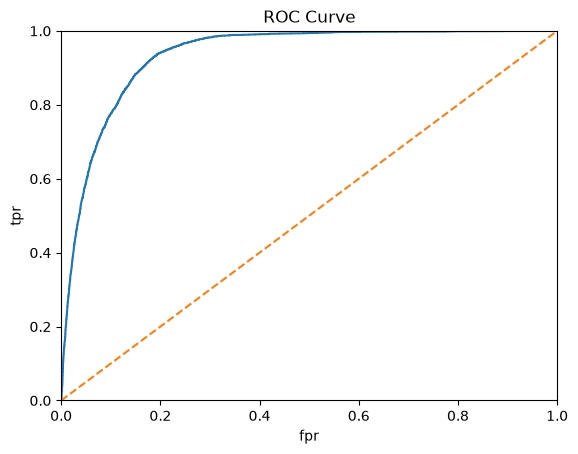

AUROC: 0.9343585328846966

------------------------------------------------------

TEST
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      7675
           1       0.41      0.67      0.51       563

    accuracy                           0.91      8238
   macro avg       0.69      0.80      0.73      8238
weighted avg       0.94      0.91      0.92      8238



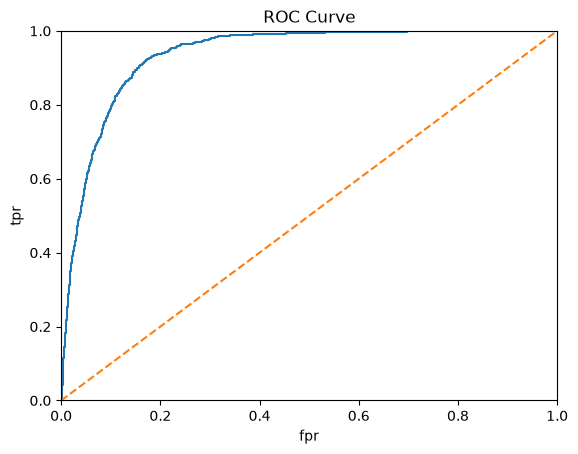

AUROC: 0.9351913710552384


In [79]:
# Transform, predict and show metrics
dp_duration = DataProcessor(raw_df, ['y'])
dp_duration.transform_columns()
dp_duration.predict_and_show_metrics(LogisticRegression(random_state=987))

## Autogluon

In [80]:
# Run autogluon predictor on raw splitted data
gluon_df = raw_df.drop('duration', axis=1).copy()
gluon_train_df, gluon_test_df = train_test_split(
    raw_df,
    test_size=0.2,
    stratify=raw_df['y'],
    random_state=15
)

predictor = TabularPredictor(
    label='y',
    positive_class='yes',
    eval_metric='roc_auc',
    verbosity=0
)
predictor.fit(
    train_data=gluon_train_df,
    presets='high_quality',
    excluded_model_types=['NN_TORCH', 'FASTAI', 'TEXT_NN_TRANSFORMER'],
    time_limit=1800
)

TRAIN
              precision    recall  f1-score   support

          no       0.98      0.96      0.97     22409
         yes       0.68      0.82      0.74      2303

    accuracy                           0.95     24712
   macro avg       0.83      0.89      0.86     24712
weighted avg       0.95      0.95      0.95     24712



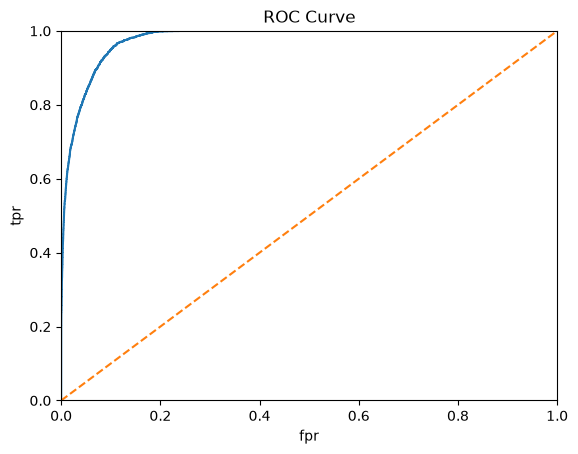

AUROC: 0.9771664963731879

------------------------------------------------------

TEST
              precision    recall  f1-score   support

          no       0.97      0.94      0.96      7508
         yes       0.54      0.68      0.60       730

    accuracy                           0.92      8238
   macro avg       0.75      0.81      0.78      8238
weighted avg       0.93      0.92      0.92      8238



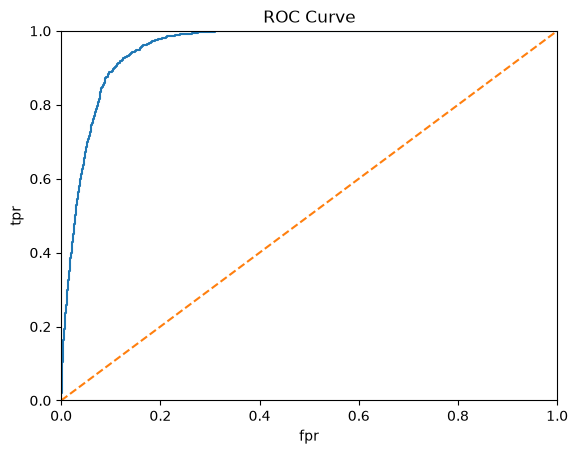

AUROC: 0.9545411929808009


In [92]:
train_preds = predictor.predict(gluon_train_df)
test_preds = predictor.predict(gluon_test_df)

train_probas = predictor.predict_proba(gluon_train_df)
test_probas = predictor.predict_proba(gluon_test_df)

print('TRAIN')
print(classification_report(train_preds, gluon_train_df['y']))
print('AUROC:', DataProcessor.get_auroc(gluon_train_df['y'], train_probas))

print('\n------------------------------------------------------\n')
print('TEST')
print(classification_report(test_preds, gluon_test_df['y']))
print('AUROC:', DataProcessor.get_auroc(gluon_test_df['y'], test_probas))

# Models comparison

## Results table

| Model | Hyperparameters | AUROC Train | AUROC Test | Recall Train | Recall Test | Comments |
| --- | --- | --- | --- | --- | --- | --- |
| Logistic Regression (default) | random_state=987 | 0.7938 | 0.7952 | 0.67 | 0.62 | Basic model, which shows pretty good AUROC values and mediocre recall. Can be improved by changing threshold value |
| Logistic Regression + PolynomialFeatures | degree=5, max_iter=200, random_state=987 | 0.7990 | 0.7992 | 0.69 | 0.62 | Slightly better than the previous one. Also can be improved by moving threshold |
| Logistic Regression + TomekLinks | random_state=987 | 0.7997 | 0.7948 | 0.70 | 0.59 | AUROC is similar to basic model but Recall on Test is worse, so I wouldn't use this model |
| Logistic Regression + Liblinear + L1 | solver='liblinear', l1_ratio=1, random_state=987 | 0.7942 | 0.7954 | 0.66 | 0.62 | Metrics are almost the same as for the basic model. Can be improved by moving threshold |
| Logistic Regression + PolynomialFeatures + Liblinear + L1 | degree=5, max_iter=200, solver='liblinear', l1_ratio=1, random_state=987 | 0.7977 | 0.7984 | 0.68 | 0.64 | Metrics are slightly better than for the basic model. Can be improved by moving threshold |
| kNN (default) | - | 0.9265 | 0.7009 | 0.74 | 0.54 | Metrics values are much better for Train set, which means that this model is overfitted |
| kNN + RandomizedSearchCV | weights='uniform', n_neighbors=199, random_state=987 | 0.8007 | 0.7847 | 0.75 | 0.73 | Pretty good AUROC values, no severe overfit and the best Recall values out of all the models. Good candidate to use as a final model |
| Decision Tree (default) | random_state=987 | 0.9999 | 0.6327 | 1.00 | 0.32 | AUROC value for Train set is almost 1 and Recall value is 1, which means this model is heavily overfitted |
| Decision Tree + RandomizedSearchCV | splitter='best', min_samples_split=7, min_samples_leaf=5, max_leaf_nodes=36, max_depth=33, criterion='entropy', random_state=987 | 0.8076 | 0.7970 | 0.67 | 0.65 | Pretty good metrics values, this model can be used |
| XGBClassifier (default) | random_state=987, eval_metric=auc | 0.9082 | 0.7891 | 0.87 | 0.57 | Metrics values are much better for Train set, which means that this model is overfitted |
| XGBClassifier + RandomizedSearchCV | n_iter=200, random_state=987, scoring='roc_auc' | 0.8323 | 0.8074 | 0.71 | 0.60 | Good AUROC values, mediocre Recall, which can be improved by using loss function related to Recall |
| XGBClassifier + Hyperopt | max_depth=13, min_child_weight=11.8308, learning_rate=0.06499, subsample=0.8244, colsample_bytree=0.8887, gamma=0.9521, reg_alpha=4.9120, reg_lambda=2.7196, n_estimators=1000, early_stopping_rounds=100 | 0.8361 | 0.8093 | 0.71 | 0.63 | Good AUROC values and decent Recall, which can be improved by using loss function related to Recall |
| LGBMClassifier (default) | random_state=987, verbose=-1 | 0.8826 | 0.8017 | 0.78 | 0.63 | Metrics values are much better for Train set, which means that this model is overfitted |
| LGBMClassifier + RandomizedSearchCV | n_iter=200, random_state=987, scoring='roc_auc' | 0.8299 | 0.8100 | 0.72 | 0.64 | Good AUROC values and decent Recall, which can be improved by using loss function related to Recall |
| LGBMClassifier + Hyperopt | learning_rate=0.2618, min_child_samples=15, num_leaves=22, max_depth=13, min_split_gain=0.4344, subsample=0.8686, colsample_bytree=0.8447, reg_alpha=0.00658, reg_lambda=4.1574, n_estimators=1000, subsample_freq=1 | 0.8235 | 0.8117 | 0.70 | 0.64 | Overall the best model. Recall can be improved if needed by business requirements |
| [BENCHMARK] Logistic Regression with 'duration' | random_state=987 | 0.9344 | 0.9352 | 0.68 | 0.67 | This model shows much better results, which is expected using 'duration' feature. Though this model can only be used as a benchmark |
| [BENCHMARK] AutoGluon | presets='high_quality', eval_metric='roc_auc', time_limit=1800 | 0.9772 | 0.9545 | 0.82 | 0.68 | Very high AUROC values and good Recall values. It means there is a potential to create better models manually |

## The best models

### kNN + RandomizedSearchCV

`KNeighborsClassifier` doesn't have build in feature_importances parameter because it treats all the features as dimensions in space. Though feature importances can be calculated, for example using SHAP.

### LGBMClassifier + Hyperopt

In [97]:
# Show feature importances
importance_df = pd.DataFrame({
    'Feature': dp_lgb_hyper.X_train.columns,
    'Importance': dp_lgb_hyper.classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df[:20]

,Feature,Importance
7,num__euribor3m,75
0,num__age,52
1,num__campaign,31
6,num__cons.conf.idx,20
5,num__cons.price.idx,16
60,cat__poutcome_failure,11
56,cat__day_of_week_mon,10
62,cat__poutcome_success,8
8,num__nr.employed,8
2,num__pdays,7


### LGBMClassifier + RandomizedSearchCV

In [99]:
# Show feature importances
importance_df = pd.DataFrame({
    'Feature': dp_lgb_rand.X_train.columns,
    'Importance': dp_lgb_rand.classifier.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df[:20]

,Feature,Importance
7,num__euribor3m,1923
0,num__age,1456
1,num__campaign,461
5,num__cons.price.idx,313
6,num__cons.conf.idx,213
43,cat__contact_cellular,199
8,num__nr.employed,143
56,cat__day_of_week_mon,131
2,num__pdays,118
60,cat__poutcome_failure,114


## Final model

Overall, the best model is `LGBMClassifier + Hyperopt`:

| Model | Hyperparameters | AUROC Train | AUROC Test | Recall Train | Recall Test |
| --- | --- | --- | --- | --- | --- |
| LGBMClassifier + Hyperopt | learning_rate=0.2618, min_child_samples=15, num_leaves=22, max_depth=13, min_split_gain=0.4344, subsample=0.8686, colsample_bytree=0.8447, reg_alpha=0.00658, reg_lambda=4.1574, n_estimators=1000, subsample_freq=1 | 0.8235 | 0.8117 | 0.70 | 0.64 |

It has good AUROC values, doesn't show overfit signs. According to importance of finding all the positive predictions, Recall can be improved via introducing loss function bound to Recall value.

### SHAP analysis of feature importances

/opt/anaconda3/envs/autogluon/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


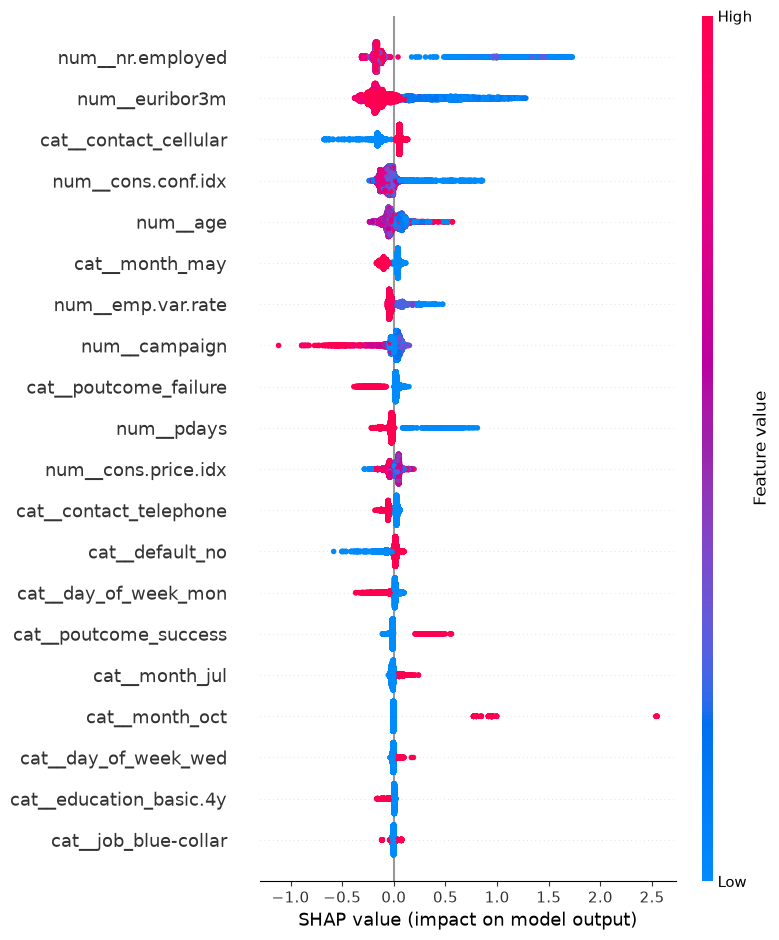

In [113]:
# Show feature importances plot
explainer = shap.TreeExplainer(dp_lgb_hyper.classifier)
shap_values = explainer.shap_values(dp_lgb_hyper.X_test)
shap.summary_plot(shap_values, dp_lgb_hyper.X_test)

**Summary**
- SHAP analysis shows that the most imortant features for this model are:
    - `nr_employed` - negative correlation (socio-economic context: number of employees)
    - `euribor3m` - negative correlation (socio-economic context: euribor 3 month rate)
    - `contact_cellular` - positive correlation (contact communication type - cellular)
    - `cons.conf.idx` - mainly negative correlation (socio-economic context: consumer confidence index)
    - `age` - mainly negative correlation (age of a client)
- Similarly to EDA, 3 out of 5 main features belong to socio-economic context.
- Apart from them, 2 other are type of contact communication and age.
- I didn't expect to see socio-economic context features dominance, I thought bank client data features would have more impact.